In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# config.on_opt_error = "ignore"

In [366]:
# 1) Read & concat your data
# files = [
#     ("OH", r"C:\Huy Phan\College\VoterTurnout\final_data\OH.csv"),
#     ("PA", r"C:\Huy Phan\College\VoterTurnout\final_data\PA.csv"),
#     ("WA", r"C:\Huy Phan\College\VoterTurnout\final_data\WA.csv"),
# ]

files = [
    ("OH", r"C:\Huy Phan\College\VoterTurnout\final_data\OH.csv")
]

# 2) Read each file, add the state column, collect into a list
dfs = []
for state, path in files:
    df_state = pd.read_csv(path)
    df_state["state"] = state
    dfs.append(df_state)

# 3) Concatenate
df = pd.concat(dfs, ignore_index=True)

# Now df["state"] is populated correctly for each precinct
print(df[["state"]].value_counts())

# 2) Precompute precinct_size and primary_turnout




state
OH       8889
Name: count, dtype: int64


In [367]:
df['primary_margin'] = np.abs(df['rep_primary_total'] - df['dem_primary_total']) / (df['rep_primary_total'] + df['dem_primary_total'])
        

In [368]:
# Calculate probability of voting for each party in the general election
df["general_turnout"] = df["rep_general_total"] + df["dem_general_total"]
df["primary_turnout"] = df["rep_primary_total"] + df["dem_primary_total"]
general_turnoutprob = 0.71 # General turnout prob for Rep
primary_turnoutprob= 0.42 # Primary turnout prob for Rep
m = general_turnoutprob / primary_turnoutprob
df["general_turnout_est"] = (df['primary_turnout'] + m * df['general_turnout']) / (1 + m **2)
df["precinct_size"] = df["general_turnout_est"] / primary_turnoutprob 

In [369]:
df[['precinct_size', 'general_turnout']]

,precinct_size,general_turnout
0,907.685525,644.0
1,705.510654,494.0
2,747.318148,511.0
3,352.461425,255.0
4,484.158707,341.0
...,...,...
8884,394.210140,282.0
8885,672.564291,492.0
8886,560.661278,409.0
8887,437.193240,309.0


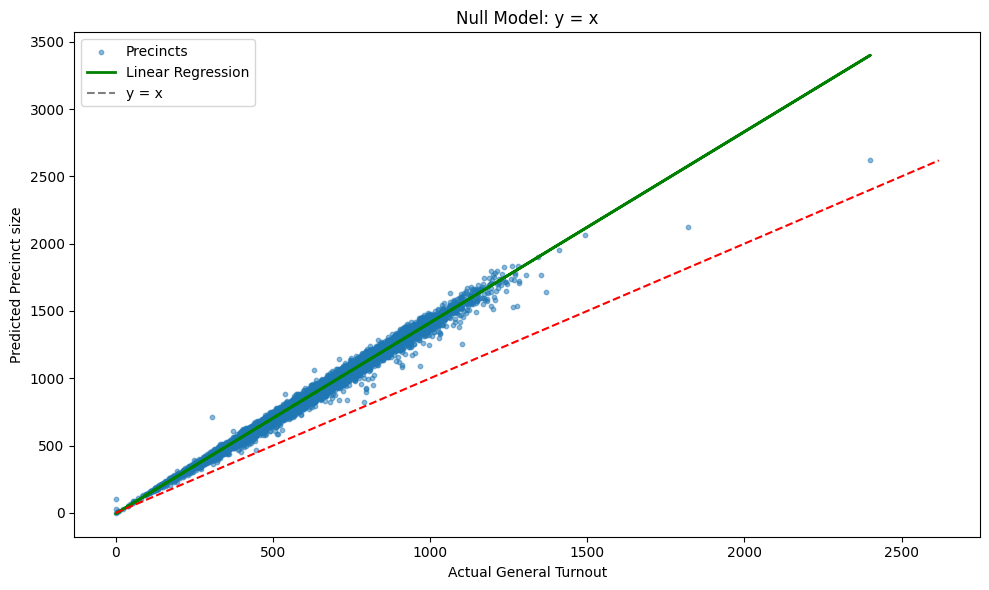

In [370]:
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(df['general_turnout'], df['precinct_size'], alpha=0.5, s=10, label='Precincts')

# Fit linear regression
X = df['general_turnout'].values.reshape(-1, 1)
y = df['precinct_size'].values
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)

# Plot regression line (x should be general_turnout, y_pred is predicted precinct_size)
plt.plot(df['general_turnout'], y_pred, color='green', linewidth=2, label='Linear Regression')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='y = x')
plt.xlabel('Actual General Turnout')
plt.ylabel('Predicted Precinct size')
plt.title('General Turnout vs Predicted Precinct size')
plt.legend()
min_val = min(df['general_turnout'].min(), df['precinct_size'].min())
max_val = max(df['general_turnout'].max(), df['precinct_size'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='y = x')

plt.xlabel('Actual General Turnout')
plt.ylabel('Predicted Precinct size')
plt.title('Null Model: y = x')
plt.tight_layout()


In [371]:
# Print regression parameters
print(f"Intercept (β₀): {reg.intercept_:.4f}")
print(f"Slope (β₁): {reg.coef_[0]:.4f}")

Intercept (β₀): -6.2477
Slope (β₁): 1.4190


In [372]:
# Estimating dem voters and rep voters based on primary turnout


df['dem_voters'] = (df['dem_primary_total'] / (df['dem_primary_total'] + df['rep_primary_total'])) * df['precinct_size']
df['rep_voters'] = (df['rep_primary_total'] / (df['dem_primary_total'] + df['rep_primary_total'])) * df['precinct_size']

In [373]:
df

,Unnamed: 0,...1,precinct,gen_rep_TRUMP,gen_dem_CLINTON,gen_rep_JOHNSON,gen_dem_STEIN,pri_dem_CLINTON,pri_dem_LA.FUENTE,pri_dem_SANDERS,...,rep_primary_entropy,dem_primary_entropy,state,primary_margin,general_turnout,primary_turnout,general_turnout_est,precinct_size,dem_voters,rep_voters
0,0,1,ADAMSAAA,532.0,96.0,12.0,4.0,27.0,1.0,26.0,...,1.201254,0.772352,OH,0.717277,644.0,382,381.227921,907.685525,128.311566,779.373959
1,1,2,ADAMSAAB,390.0,95.0,9.0,0.0,36.0,0.0,28.0,...,1.183869,0.685314,OH,0.584416,494.0,308,296.314475,705.510654,146.599616,558.911038
2,2,3,ADAMSAAD,408.0,94.0,5.0,4.0,39.0,0.0,34.0,...,1.035883,0.690800,OH,0.579251,511.0,347,313.873622,747.318148,157.216786,590.101362
3,3,4,ADAMSAAE,176.0,76.0,2.0,1.0,35.0,0.0,22.0,...,1.001498,0.666909,OH,0.185714,255.0,140,148.033799,352.461425,143.502152,208.959274
4,4,5,ADAMSAAG,258.0,73.0,8.0,2.0,22.0,1.0,21.0,...,1.121784,0.785601,OH,0.576923,341.0,208,203.346657,484.158707,102.418188,381.740519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8884,8884,8885,WYANDOTABH,221.0,45.0,13.0,3.0,17.0,1.0,8.0,...,1.093819,0.765783,OH,0.679012,282.0,162,165.568259,394.210140,63.268294,330.941846
8885,8885,8886,WYANDOTABI,368.0,103.0,19.0,2.0,38.0,1.0,18.0,...,1.141249,0.705245,OH,0.558140,492.0,258,282.477002,672.564291,148.589785,523.974506
8886,8886,8887,WYANDOTABJ,293.0,100.0,13.0,3.0,31.0,1.0,28.0,...,1.176493,0.765089,OH,0.447005,409.0,217,235.477737,560.661278,155.021552,405.639727
8887,8887,8888,WYANDOTABL,241.0,55.0,12.0,1.0,20.0,1.0,15.0,...,1.124105,0.790869,OH,0.612903,309.0,186,183.621161,437.193240,84.618047,352.575194


In [374]:
df['primary_winner'] = np.where(
    df['rep_primary_total'] > df['dem_primary_total'], 'rep', 'dem'
)

# Calculate probability for the winner and loser
df['prob_winner'] = np.where(
    df['primary_winner'] == 'rep',
    df['rep_general_total'] / df['rep_voters'],
    df['dem_general_total'] / df['dem_voters']
)
df['prob_loser'] = np.where(
    df['primary_winner'] == 'rep',
    df['dem_general_total'] / df['rep_voters'],
    df['rep_general_total'] / df['dem_voters']
)

In [375]:
df

,Unnamed: 0,...1,precinct,gen_rep_TRUMP,gen_dem_CLINTON,gen_rep_JOHNSON,gen_dem_STEIN,pri_dem_CLINTON,pri_dem_LA.FUENTE,pri_dem_SANDERS,...,primary_margin,general_turnout,primary_turnout,general_turnout_est,precinct_size,dem_voters,rep_voters,primary_winner,prob_winner,prob_loser
0,0,1,ADAMSAAA,532.0,96.0,12.0,4.0,27.0,1.0,26.0,...,0.717277,644.0,382,381.227921,907.685525,128.311566,779.373959,rep,0.697996,0.128308
1,1,2,ADAMSAAB,390.0,95.0,9.0,0.0,36.0,0.0,28.0,...,0.584416,494.0,308,296.314475,705.510654,146.599616,558.911038,rep,0.713888,0.169973
2,2,3,ADAMSAAD,408.0,94.0,5.0,4.0,39.0,0.0,34.0,...,0.579251,511.0,347,313.873622,747.318148,157.216786,590.101362,rep,0.699880,0.166073
3,3,4,ADAMSAAE,176.0,76.0,2.0,1.0,35.0,0.0,22.0,...,0.185714,255.0,140,148.033799,352.461425,143.502152,208.959274,rep,0.851841,0.368493
4,4,5,ADAMSAAG,258.0,73.0,8.0,2.0,22.0,1.0,21.0,...,0.576923,341.0,208,203.346657,484.158707,102.418188,381.740519,rep,0.696808,0.196469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8884,8884,8885,WYANDOTABH,221.0,45.0,13.0,3.0,17.0,1.0,8.0,...,0.679012,282.0,162,165.568259,394.210140,63.268294,330.941846,rep,0.707073,0.145041
8885,8885,8886,WYANDOTABI,368.0,103.0,19.0,2.0,38.0,1.0,18.0,...,0.558140,492.0,258,282.477002,672.564291,148.589785,523.974506,rep,0.738586,0.200391
8886,8886,8887,WYANDOTABJ,293.0,100.0,13.0,3.0,31.0,1.0,28.0,...,0.447005,409.0,217,235.477737,560.661278,155.021552,405.639727,rep,0.754364,0.253920
8887,8887,8888,WYANDOTABL,241.0,55.0,12.0,1.0,20.0,1.0,15.0,...,0.612903,309.0,186,183.621161,437.193240,84.618047,352.575194,rep,0.717577,0.158831


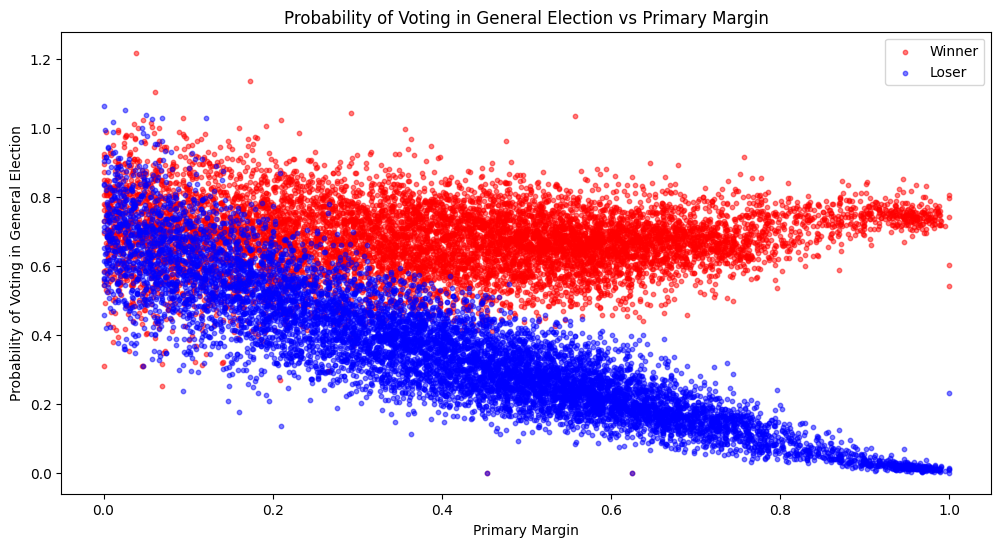

In [376]:
plt.figure(figsize=(12, 6))

plt.scatter(
    x=df['primary_margin'], 
    y=df['prob_winner'], 
    color='red', label='Winner', alpha=0.5, s=10
)
plt.scatter(
    x=df['primary_margin'], 
    y=df['prob_loser'], 
    color='blue', label='Loser', alpha=0.5, s=10
)

plt.title('Probability of Voting in General Election vs Primary Margin')
plt.xlabel('Primary Margin')
plt.ylabel('Probability of Voting in General Election')
plt.legend()


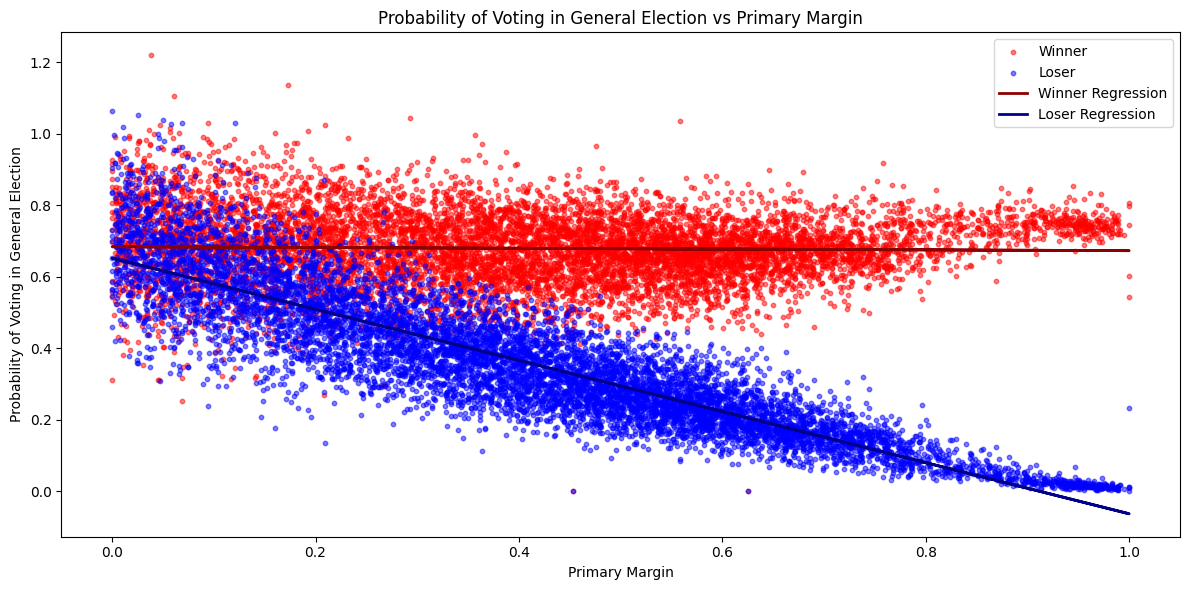

Winner Intercept (β₀): 0.6837
Winner Slope (β₁): -0.0111
Loser Intercept (β₀): 0.6518
Loser Slope (β₁): -0.7153


In [377]:
plt.figure(figsize=(12, 6))

# Drop rows with NaN in any relevant column
df_clean = df.dropna(subset=['primary_margin', 'prob_winner', 'prob_loser'])

plt.scatter(
    x=df_clean['primary_margin'], 
    y=df_clean['prob_winner'], 
    color='red', label='Winner', alpha=0.5, s=10
)
plt.scatter(
    x=df_clean['primary_margin'], 
    y=df_clean['prob_loser'], 
    color='blue', label='Loser', alpha=0.5, s=10
)

from sklearn.linear_model import LinearRegression
X_margin = df_clean['primary_margin'].values.reshape(-1, 1)

# Winner regression
reg_winner = LinearRegression().fit(X_margin, df_clean['prob_winner'].values)
y_pred_winner = reg_winner.predict(X_margin)
plt.plot(
    df_clean['primary_margin'], y_pred_winner, color='darkred', linewidth=2, label='Winner Regression'
)

# Loser regression
reg_loser = LinearRegression().fit(X_margin, df_clean['prob_loser'].values)
y_pred_loser = reg_loser.predict(X_margin)
plt.plot(
    df_clean['primary_margin'], y_pred_loser, color='darkblue', linewidth=2, label='Loser Regression'
)

plt.title('Probability of Voting in General Election vs Primary Margin')
plt.xlabel('Primary Margin')
plt.ylabel('Probability of Voting in General Election')
plt.legend()
plt.tight_layout()
plt.show()

# Print the 4 regression parameters
print(f"Winner Intercept (β₀): {reg_winner.intercept_:.4f}")
print(f"Winner Slope (β₁): {reg_winner.coef_[0]:.4f}")
print(f"Loser Intercept (β₀): {reg_loser.intercept_:.4f}")
print(f"Loser Slope (β₁): {reg_loser.coef_[0]:.4f}")